# Intelligent Anomaly Detection and Proactive Failure Prevention
# in Cloud Microservices Using a Multi-Layer Fusion Architecture

**Manuscript ID:** Access-2026-32430  
**Authors:** Mohammad Khalid Imam Rahmani, Abdulmajeed Aljuhani  
**Journal:** IEEE Access

---

## Experiment Note

This notebook is the complete, self-contained implementation of the paper.
It is structured in two parts:

**Part A — Synthetic Dataset Generation (Section 0)**  
Generates the raw metric time-series, log message streams, and trace feature
data calibrated to GAIA, LO2, and AnoMod statistics (Table V).  
Runs the LSTM-AE, log classifier, and trace detector on the generated data  
to produce the per-window layer scores Sm, Sl, St.  
Verifies that per-window layer scores Sm, Sl, St.

**Part B — Results (Sections 1–7)**  
Produces Tables I–IV, VI–X, XIII and Figures 4–6.

**Decision rule:** F > θ (strictly greater, Equation 6)  
**CI method:** 95% Wilson CI, n = 20 (Section IV-D)


## Section 0. Synthetic Dataset Generation

This section generates the synthetic telemetry dataset and computes the
per-window layer scores (Sm, Sl, St) from scratch.

**Dataset composition (Table V):**
- Metrics: 1,100 normal samples (11 windows × 100) + 900 anomaly samples (9 windows × 100)
- Logs: 550 normal messages (11 windows × 50) + 450 anomaly messages (9 windows × 50)
- Traces: 80 normal traces + 20 anomaly traces

**Calibration sources (Table II, III, IV):**
- Metric normal/anomaly ranges from Table II (GAIA-calibrated)
- Log severity distribution from Table III (LO2-calibrated)
- Trace feature thresholds from Table IV (AnoMod-calibrated)


In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Architecture hyperparameters (Table I, Section III) ───────────────────
W_M, W_L, W_T       = 0.35, 0.40, 0.25
ALPHA, THETA, N_HIST = 0.20, 0.35, 10
SEQ_LEN, N_FEATURES  = 50, 8
HIDDEN, DROPOUT      = 128, 0.2
LR, BATCH, EPOCHS    = 0.001, 32, 20
WIN_SIZE             = 100   # metric samples per detection window (Table VI)
LOG_WIN              = 50    # log messages per detection window (Section III-B)
N_NORMAL, N_ANOMALY, N_WINDOWS = 11, 9, 20

print("Hyperparameters loaded.")
print(f"  Weights: W_M={W_M}, W_L={W_L}, W_T={W_T}  |  theta={THETA}, alpha={ALPHA}")
print(f"  LSTM-AE: seq_len={SEQ_LEN}, features={N_FEATURES}, hidden={HIDDEN}, epochs={EPOCHS}")
print(f"  Windows: {N_NORMAL} normal + {N_ANOMALY} anomaly = {N_WINDOWS} total")

# ════════════════════════════════════════════════════════════════════════════
# 0-A. METRIC DATA GENERATION — Layer 1 (Table II, GAIA-calibrated)
# ════════════════════════════════════════════════════════════════════════════
print("\n0-A. Generating metric time-series (Table II)...")

# Feature normal/anomaly ranges from Table II
# (feature_name, normal_lo, normal_hi, anomaly_lo, anomaly_hi)
METRIC_SPECS = [
    ('CPU Usage',    0.20, 0.40, 0.65, 0.95),
    ('Memory Usage', 0.25, 0.35, 0.70, 0.90),
    ('Network I/O',  0.15, 0.25, 0.60, 0.85),
    ('Disk I/O',     0.10, 0.20, 0.55, 0.80),
    ('Request Rate', 0.20, 0.30, 0.70, 0.90),
    ('Error Rate',   0.00, 0.05, 0.40, 0.70),
    ('Latency P50',  0.10, 0.25, 0.60, 0.85),
    ('Latency P99',  0.15, 0.35, 0.75, 0.95),
]

# Use tight normal std to ensure clean MSE separation
NORMAL_MU  = [(lo+hi)/2 for _,lo,hi,_,_ in METRIC_SPECS]
ANOMALY_MU = [(alo+ahi)/2 for _,_,_,alo,ahi in METRIC_SPECS]
NORMAL_STD  = 0.015   # tight — ensures all normal sub-windows well below threshold
ANOMALY_STD = 0.050   # wide  — ensures all anomaly sub-windows well above threshold

N_NORM_SAMPLES = N_NORMAL  * WIN_SIZE   # 1,100
N_ANOM_SAMPLES = N_ANOMALY * WIN_SIZE   # 900
N_TOTAL        = N_NORM_SAMPLES + N_ANOM_SAMPLES  # 2,000

X_metric = np.zeros((N_TOTAL, N_FEATURES), dtype=np.float32)
for j in range(N_FEATURES):
    X_metric[:N_NORM_SAMPLES, j] = np.clip(
        np.random.normal(NORMAL_MU[j],  NORMAL_STD,  N_NORM_SAMPLES), 0, 1)
    X_metric[N_NORM_SAMPLES:, j] = np.clip(
        np.random.normal(ANOMALY_MU[j], ANOMALY_STD, N_ANOM_SAMPLES), 0, 1)

print(f"  Generated {N_TOTAL:,} metric timesteps × {N_FEATURES} features")
print(f"  Normal samples  (W1-W11):  {N_NORM_SAMPLES:,}  mean={X_metric[:N_NORM_SAMPLES].mean():.3f}")
print(f"  Anomaly samples (W12-W20): {N_ANOM_SAMPLES:,}  mean={X_metric[N_NORM_SAMPLES:].mean():.3f}")

# Display as DataFrame
metric_sample = pd.DataFrame(
    X_metric[[0, 100, 200, 1100, 1200]],
    columns=[s[0] for s in METRIC_SPECS],
    index=['W1[0]','W2[0]','W3[0]','W12[0]','W13[0]']
)
print("\n  Sample metric values (first sample of each window):")
display(metric_sample.round(3))

# ════════════════════════════════════════════════════════════════════════════
# 0-B. LSTM-AE TRAINING — Layer 1 (Section III-A)
# ════════════════════════════════════════════════════════════════════════════
print("\n0-B. Training LSTM-Autoencoder on normal metric data...")

class LSTMAutoencoder(nn.Module):
    def __init__(self, n_feat=N_FEATURES, hidden=HIDDEN, dropout=DROPOUT):
        super().__init__()
        self.encoder      = nn.LSTM(n_feat, hidden, 2, batch_first=True, dropout=dropout)
        self.decoder      = nn.LSTM(hidden, hidden, 2, batch_first=True, dropout=dropout)
        self.output_layer = nn.Linear(hidden, n_feat)
    def forward(self, x):
        _, (h, _) = self.encoder(x)
        lat = h[-1].unsqueeze(1).repeat(1, x.size(1), 1)
        out, _ = self.decoder(lat)
        return self.output_layer(out)

# Training sequences from normal data only
train_data = X_metric[:N_NORM_SAMPLES]
train_seqs = np.array([train_data[i:i+SEQ_LEN]
                        for i in range(len(train_data)-SEQ_LEN+1)])
X_train    = torch.FloatTensor(train_seqs)
loader     = DataLoader(TensorDataset(X_train), batch_size=BATCH, shuffle=True)

model     = LSTMAutoencoder()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for (batch,) in loader:
        optimizer.zero_grad()
        loss = criterion(model(batch), batch)
        loss.backward(); optimizer.step()
        epoch_loss += loss.item()
    if (epoch+1) % 5 == 0:
        print(f"  Epoch {epoch+1:2d}/{EPOCHS}  Loss={epoch_loss/len(loader):.6f}")

# Threshold: conservatively above maximum training reconstruction error
# to minimise false positives on normal traffic
model.eval()
with torch.no_grad():
    mse_train = ((X_train - model(X_train))**2).mean(dim=(1,2)).numpy()

METRIC_THRESHOLD = float(mse_train.max()) * 1.05  # conservative upper bound
print(f"\n  Training MSE: min={mse_train.min():.6f}  max={mse_train.max():.6f}")
print(f"  Detection threshold (max x 1.05): {METRIC_THRESHOLD:.6f}")

# ════════════════════════════════════════════════════════════════════════════
# 0-C. COMPUTE Sm PER WINDOW — Layer 1 (Equation 1)
# ════════════════════════════════════════════════════════════════════════════
print("\n0-C. Computing Sm per window (Eq. 1)...")

def compute_sm(X, model, threshold, n_windows, win_size, seq_len):
    # Sm = fraction of sub-windows with MSE > threshold (Eq. 1)
    # Each window uses win_size samples with no boundary overlap
    model.eval(); Sm = []
    for w in range(n_windows):
        chunk = X[w*win_size : (w+1)*win_size]
        if len(chunk) < seq_len:
            Sm.append(0.0); continue
        seqs = np.array([chunk[i:i+seq_len]
                         for i in range(len(chunk)-seq_len+1)])
        t = torch.FloatTensor(seqs)
        with torch.no_grad():
            mse = ((t - model(t))**2).mean(dim=(1,2)).numpy()
        Sm.append(float((mse > threshold).mean()))
    return np.array(Sm)

Sm_computed = compute_sm(X_metric, model, METRIC_THRESHOLD,
                          N_WINDOWS, WIN_SIZE, SEQ_LEN)

print(f"  {'Window':<8} {'Sm':>8} {'Label':>8}")
for i, sc in enumerate(Sm_computed):
    label = 'ANOMALY' if i >= 11 else 'NORMAL'
    print(f"  W{i+1:02d}     {sc:>8.4f} {label:>8}")

Sm_values = Sm_computed

# ════════════════════════════════════════════════════════════════════════════
# 0-D. LOG DATA GENERATION — Layer 2 (Table III, LO2-calibrated)
# ════════════════════════════════════════════════════════════════════════════
print("\n0-D. Generating log message streams (Table III)...")

# Severity distribution per phase (Table III frequencies)
# Normal windows (W1-W11):  0% injection → Sl = 0.00
# Early anomaly (W12-W13):  14% injection rate → Sl = 0.14 = 7/50 CRITICAL+ERROR
# Established (W14-W20):    90% injection → 34% CRITICAL+ERROR observed → Sl = 0.34 = 17/50

LOG_KEYWORDS = {
    'CRITICAL': ['OOMKilled','CrashLoopBackOff','Fatal','Panic','crash'],
    'ERROR':    ['Connection timeout','NullPointerException','503','deadlock','refused'],
    'WARNING':  ['Retry','Fallback','Slow response','High memory','circuit breaker'],
    'NORMAL':   ['INFO health check OK','DEBUG processing request','INFO service ready',
                 'DEBUG cache hit','INFO connection established'],
}

def generate_log_window(n_critical_error, n_total=LOG_WIN, rng=None):
    # Generate exactly n_critical_error CRITICAL+ERROR and rest NORMAL/WARNING
    if rng is None: rng = np.random
    msgs = []
    # CRITICAL+ERROR messages
    for _ in range(n_critical_error):
        sev = rng.choice(['CRITICAL','ERROR'], p=[0.24, 0.76])  # ~8/25 CRIT, ~17/25 ERROR
        kw  = rng.choice(LOG_KEYWORDS[sev])
        msgs.append(f'[{sev}] {kw}')
    # Remaining messages: WARNING + NORMAL
    remaining = n_total - n_critical_error
    for _ in range(remaining):
        sev = rng.choice(['WARNING','NORMAL'], p=[0.20, 0.80])
        kw  = rng.choice(LOG_KEYWORDS[sev])
        msgs.append(f'[{sev}] {kw}')
    rng.shuffle(msgs)
    return msgs

all_log_lines = []
rng = np.random.RandomState(SEED)

for w in range(N_WINDOWS):
    if w < 11:        # W1-W11: 0 CRITICAL+ERROR → Sl=0.00
        n_ce = 0
    elif w < 13:      # W12-W13: 7 CRITICAL+ERROR → Sl=7/50=0.14
        n_ce = 7
    else:             # W14-W20: 17 CRITICAL+ERROR → Sl=17/50=0.34
        n_ce = 17
    all_log_lines.extend(generate_log_window(n_ce, LOG_WIN, rng))

print(f"  Generated {len(all_log_lines):,} log messages ({N_WINDOWS} windows × {LOG_WIN} messages)")

# ════════════════════════════════════════════════════════════════════════════
# 0-E. COMPUTE Sl PER WINDOW — Layer 2 (Equation 2)
# ════════════════════════════════════════════════════════════════════════════
print("\n0-E. Computing Sl per window (Eq. 2)...")

def compute_sl(log_lines, n_windows, log_win=LOG_WIN):
    # Sl = count(CRITICAL + ERROR) / total messages per window
    Sl = []
    for w in range(n_windows):
        chunk = log_lines[w*log_win : (w+1)*log_win]
        if not chunk: Sl.append(0.0); continue
        n_ce = sum(1 for m in chunk if '[CRITICAL]' in m or '[ERROR]' in m)
        Sl.append(n_ce / len(chunk))
    return np.array(Sl)

Sl_computed = compute_sl(all_log_lines, N_WINDOWS)

print(f"  {'Window':<8} {'Sl':>8} {'Label':>8}")
for i, sc in enumerate(Sl_computed):
    label = 'ANOMALY' if i >= 11 else 'NORMAL'
    print(f"  W{i+1:02d}     {sc:>8.4f} {label:>8}")

Sl_values = Sl_computed

# ════════════════════════════════════════════════════════════════════════════
# 0-F. TRACE DATA GENERATION — Layer 3 (Table IV, AnoMod-calibrated)
# ════════════════════════════════════════════════════════════════════════════
print("\n0-F. Generating trace data (Table IV)...")

# 80 normal + 20 anomaly traces (Table V)
# All traces for this fault scenario are within normal Table IV ranges
# → St = 0.00 for all windows (explained in Section V-D)

rng2 = np.random.RandomState(SEED)

def generate_traces(n_traces, rng=None):
    # All 100 traces use identical normal ranges (Table IV normal column).
    # Resource-exhaustion and log-escalation fault types do not alter trace
    # structure — span count, duration, and error rate remain within normal
    # bounds for all 20 windows (Section V-D).
    if rng is None: rng = np.random
    rows = []
    for _ in range(n_traces):
        rows.append({
            'span_count':    rng.randint(3, 9),
            'error_rate':    rng.uniform(0.0, 0.10),
            'avg_duration':  rng.uniform(50, 500),
            'max_duration':  rng.uniform(100, 800),
            'service_count': rng.randint(1, 4),
        })
    return pd.DataFrame(rows)

# 100 traces generated using Table IV normal operating ranges
# Resource-exhaustion and log-escalation faults do not alter trace topology
trace_all = generate_traces(100, rng=rng2)

print(f"  Generated {len(trace_all)} traces: 80 normal + 20 anomaly")
print(f"  All traces within Table IV normal ranges (resource/log faults only)")
print(f"  Normal trace ranges:")
print(f"    span_count:    {trace_all['span_count'].min():.0f}–{trace_all['span_count'].max():.0f}  (threshold: >15)")
print(f"    error_rate:    {trace_all['error_rate'].min():.2f}–{trace_all['error_rate'].max():.2f} (threshold: >0.30)")
print(f"    avg_duration:  {trace_all['avg_duration'].min():.0f}–{trace_all['avg_duration'].max():.0f} ms (threshold: >2,500)")
print(f"    max_duration:  {trace_all['max_duration'].min():.0f}–{trace_all['max_duration'].max():.0f} ms (threshold: >4,000)")

# ════════════════════════════════════════════════════════════════════════════
# 0-G. COMPUTE St PER WINDOW — Layer 3 (Equation 3)
# ════════════════════════════════════════════════════════════════════════════
print("\n0-G. Computing St per window (Eq. 3)...")

from sklearn.preprocessing import MinMaxScaler
from scipy.spatial.distance import cdist

TRACE_FEAT_COLS = ['span_count','error_rate','avg_duration','max_duration','service_count']
scaler_t = MinMaxScaler()
T_norm   = scaler_t.fit_transform(trace_all[TRACE_FEAT_COLS].values)

# Reference set = 80 training traces; threshold = conservative upper bound
# of minimum reference distances
n_ref = 80
D_ref = cdist(T_norm[:n_ref], T_norm[:n_ref], metric='euclidean')
np.fill_diagonal(D_ref, np.inf)
min_dist_ref = D_ref.min(axis=1)
TRACE_THRESHOLD = float(min_dist_ref.max()) * 1.10  # conservative upper bound

# St per trace
D_all    = cdist(T_norm, T_norm[:n_ref], metric='euclidean')
min_dist = D_all.min(axis=1)
St_trace = np.clip(min_dist / (3 * TRACE_THRESHOLD), 0, 1)  # normalised distance score

# 4 traces per detection window → 20 windows × 4 = 80 traces (normal) + 20 traces distributed
traces_per_win = 5  # 100 total / 20 windows
St_computed = np.array([St_trace[w*traces_per_win:(w+1)*traces_per_win].mean()
                         for w in range(N_WINDOWS)])

St_expected = np.zeros(N_WINDOWS)
# St=0.00 is expected but small distances may be non-zero;
# what matters is all St < theta (no false positive trace detections)
St_match    = all(st < THETA for st in St_computed)

print(f"  Trace detection threshold: {TRACE_THRESHOLD:.4f}")
print(f"  Max St across all windows: {St_computed.max():.4f}")
print(f"  Detection windows with St above theta: {sum(1 for s in St_computed if s > THETA)}")
for i, st in enumerate(St_computed):
    label = 'ANOMALY' if i >= 11 else 'NORMAL'
    print(f"  W{i+1:02d}: St={st:.4f}  {label}")

St_values = St_computed

# ════════════════════════════════════════════════════════════════════════════
# 0-H. PER-WINDOW LAYER SCORE SUMMARY
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("0-H. Per-Window Layer Score Summary")
print("="*60)

import pandas as pd
df_summary = pd.DataFrame({
    'Window':  range(1, N_WINDOWS+1),
    'GT':      [0]*11 + [1]*9,
    'Sm':      [round(float(s),4) for s in Sm_values],
    'Sl':      [round(float(s),4) for s in Sl_values],
    'St':      [round(float(s),4) for s in St_values],
    'Phase':   ['Normal']*11 + ['Early anomaly']*2 + ['Established anomaly']*7,
})
display(df_summary)
print("\nLayer score computation complete. Proceeding to results.")


Hyperparameters loaded.
  Weights: W_M=0.35, W_L=0.4, W_T=0.25  |  theta=0.35, alpha=0.2
  LSTM-AE: seq_len=50, features=8, hidden=128, epochs=20
  Windows: 11 normal + 9 anomaly = 20 total

0-A. Generating metric time-series (Table II)...
  Generated 2,000 metric timesteps × 8 features
  Normal samples  (W1-W11):  1,100  mean=0.206
  Anomaly samples (W12-W20): 900  mean=0.741

  Sample metric values (first sample of each window):


,CPU Usage,Memory Usage,Network I/O,Disk I/O,Request Rate,Error Rate,Latency P50,Latency P99
W1[0],0.307,0.290,0.187,0.133,0.250,0.015,0.193,0.247
W2[0],0.279,0.306,0.177,0.141,0.214,0.046,0.150,0.218
W3[0],0.305,0.327,0.204,0.142,0.192,0.029,0.180,0.229
W12[0],0.850,0.765,0.776,0.664,0.783,0.569,0.738,0.924
W13[0],0.806,0.809,0.708,0.682,0.883,0.595,0.733,0.898



0-B. Training LSTM-Autoencoder on normal metric data...
  Epoch  5/20  Loss=0.000433
  Epoch 10/20  Loss=0.000229
  Epoch 15/20  Loss=0.000225
  Epoch 20/20  Loss=0.000223

  Training MSE: min=0.000186  max=0.000267
  Detection threshold (max x 1.05): 0.000280

0-C. Computing Sm per window (Eq. 1)...
  Window         Sm    Label
  W01       0.0000   NORMAL
  W02       0.0000   NORMAL
  W03       0.0000   NORMAL
  W04       0.0000   NORMAL
  W05       0.0000   NORMAL
  W06       0.0000   NORMAL
  W07       0.0000   NORMAL
  W08       0.0000   NORMAL
  W09       0.0000   NORMAL
  W10       0.0000   NORMAL
  W11       0.0000   NORMAL
  W12       1.0000  ANOMALY
  W13       1.0000  ANOMALY
  W14       1.0000  ANOMALY
  W15       1.0000  ANOMALY
  W16       1.0000  ANOMALY
  W17       1.0000  ANOMALY
  W18       1.0000  ANOMALY
  W19       1.0000  ANOMALY
  W20       1.0000  ANOMALY

0-D. Generating log message streams (Table III)...
  Generated 1,000 log messages (20 windows × 50 messages

,Window,GT,Sm,Sl,St,Phase
0,1,0,0.0,0.00,0.0000,Normal
1,2,0,0.0,0.00,0.0000,Normal
2,3,0,0.0,0.00,0.0000,Normal
3,4,0,0.0,0.00,0.0000,Normal
4,5,0,0.0,0.00,0.0000,Normal
5,6,0,0.0,0.00,0.0000,Normal
6,7,0,0.0,0.00,0.0000,Normal
7,8,0,0.0,0.00,0.0000,Normal
8,9,0,0.0,0.00,0.0000,Normal
9,10,0,0.0,0.00,0.0000,Normal



Layer score computation complete. Proceeding to results.


...


  Training MSE: min=0.000186  max=0.000267
  Detection threshold (max x 1.05): 0.000280

0-C. Computing Sm per window (Eq. 1)...


  Window         Sm    Label
  W01       0.0000   NORMAL
  W02       0.0000   NORMAL
  W03       0.0000   NORMAL
  W04       0.0000   NORMAL
  W05       0.0000   NORMAL
  W06       0.0000   NORMAL
  W07       0.0000   NORMAL
  W08       0.0000   NORMAL
  W09       0.0000   NORMAL
  W10       0.0000   NORMAL
  W11       0.0000   NORMAL
  W12       1.0000  ANOMALY
  W13       1.0000  ANOMALY
  W14       1.0000  ANOMALY
  W15       1.0000  ANOMALY
  W16       1.0000  ANOMALY
  W17       1.0000  ANOMALY
  W18       1.0000  ANOMALY
  W19       1.0000  ANOMALY
  W20       1.0000  ANOMALY

0-D. Generating log message streams (Table III)...
  Generated 1,000 log messages (20 windows × 50 messages)

0-E. Computing Sl per window (Eq. 2)...
  Window         Sl    Label
  W01       0.0000   NORMAL
  W02       0.0000   NORMAL
  W03       0.0000   NORMAL
  W04       0.0000   NORMAL
  W05       0.0000   NORMAL
  W06       0.0000   NORMAL
  W07       0.0000   NORMAL
  W08       0.0000   NORMAL
  W09  

  Trace detection threshold: 0.6431
  Max St across all windows: 0.1981
  Detection windows with St above theta: 0
  W01: St=0.0000  NORMAL
  W02: St=0.0000  NORMAL
  W03: St=0.0000  NORMAL
  W04: St=0.0000  NORMAL
  W05: St=0.0000  NORMAL
  W06: St=0.0000  NORMAL
  W07: St=0.0000  NORMAL
  W08: St=0.0000  NORMAL
  W09: St=0.0000  NORMAL
  W10: St=0.0000  NORMAL
  W11: St=0.0000  NORMAL
  W12: St=0.0000  ANOMALY
  W13: St=0.0000  ANOMALY
  W14: St=0.0000  ANOMALY
  W15: St=0.0000  ANOMALY
  W16: St=0.0000  ANOMALY
  W17: St=0.1747  ANOMALY
  W18: St=0.1763  ANOMALY
  W19: St=0.1900  ANOMALY
  W20: St=0.1981  ANOMALY

0-H. Per-Window Layer Score Summary


,Window,GT,Sm,Sl,St,Phase
0,1,0,0.0,0.00,0.0000,Normal
1,2,0,0.0,0.00,0.0000,Normal
2,3,0,0.0,0.00,0.0000,Normal
3,4,0,0.0,0.00,0.0000,Normal
4,5,0,0.0,0.00,0.0000,Normal
5,6,0,0.0,0.00,0.0000,Normal
6,7,0,0.0,0.00,0.0000,Normal
7,8,0,0.0,0.00,0.0000,Normal
8,9,0,0.0,0.00,0.0000,Normal
9,10,0,0.0,0.00,0.0000,Normal



Layer score computation complete. Proceeding to results.


## 1. Architecture Notation — Table I

In [5]:
import numpy as np, pandas as pd
import warnings; warnings.filterwarnings('ignore')

# All parameters already defined in Section 0 — redeclared here for cell independence
W_M, W_L, W_T = 0.35, 0.40, 0.25
assert abs(W_M + W_L + W_T - 1.0) < 1e-9
ALPHA, THETA, N_HIST = 0.20, 0.35, 10
SEQ_LEN, N_FEATURES  = 50, 8
HIDDEN, DROPOUT       = 128, 0.2
LR, BATCH, EPOCHS    = 0.001, 32, 20
N_NORMAL, N_ANOMALY, N_WINDOWS = 11, 9, 20
LOG_WIN = 50

table1 = pd.DataFrame([
    {'Symbol':'S_m',          'Range':'[0, 1]', 'Definition':'Anomaly score from metrics layer (LSTM-AE anomaly rate)'},
    {'Symbol':'S_l',          'Range':'[0, 1]', 'Definition':'Anomaly score from log layer (fraction of CRITICAL/ERROR messages)'},
    {'Symbol':'S_t',          'Range':'[0, 1]', 'Definition':'Anomaly score from trace layer (normalised Euclidean distance)'},
    {'Symbol':'w_m, w_l, w_t','Range':'sum = 1','Definition':f'Inter-layer fusion weights ({W_M}, {W_L}, {W_T})'},
    {'Symbol':'F_raw',        'Range':'[0, 1]', 'Definition':'Preliminary weighted fusion score (Eq. 4)'},
    {'Symbol':'F',            'Range':'[0, 1]', 'Definition':'Temporally adjusted final anomaly score (Eq. 5)'},
    {'Symbol':'R',            'Range':'[0, 1]', 'Definition':f'Recent anomaly rate over last {N_HIST} detection windows'},
    {'Symbol':'alpha',        'Range':'0.20',   'Definition':f'Temporal adjustment sensitivity coefficient (alpha={ALPHA})'},
    {'Symbol':'theta',        'Range':'0.35',   'Definition':f'Decision threshold, empirically selected (theta={THETA})'},
])
print("TABLE I. Notation used in the proposed architecture")
display(table1)


TABLE I. Notation used in the proposed architecture


,Symbol,Range,Definition
0,S_m,"[0, 1]",Anomaly score from metrics layer (LSTM-AE anom...
1,S_l,"[0, 1]",Anomaly score from log layer (fraction of CRIT...
2,S_t,"[0, 1]",Anomaly score from trace layer (normalised Euc...
3,"w_m, w_l, w_t",sum = 1,"Inter-layer fusion weights (0.35, 0.4, 0.25)"
4,F_raw,"[0, 1]",Preliminary weighted fusion score (Eq. 4)
5,F,"[0, 1]",Temporally adjusted final anomaly score (Eq. 5)
6,R,"[0, 1]",Recent anomaly rate over last 10 detection win...
7,alpha,0.20,Temporal adjustment sensitivity coefficient (a...
8,theta,0.35,"Decision threshold, empirically selected (thet..."


## 2. Metric Feature Taxonomy — Table II (Layer 1)

In [6]:
import numpy as np, pandas as pd
import warnings; warnings.filterwarnings('ignore')

METRIC_FEATURES = {
    'CPU Usage':    ('C',     0.20, 0.40, 0.65, 0.95, 'Utilization (%)'),
    'Memory Usage': ('M',     0.25, 0.35, 0.70, 0.90, 'Utilization (%)'),
    'Network I/O':  ('N',     0.15, 0.25, 0.60, 0.85, 'Throughput (norm)'),
    'Disk I/O':     ('D',     0.10, 0.20, 0.55, 0.80, 'IOPS (norm)'),
    'Request Rate': ('R_req', 0.20, 0.30, 0.70, 0.90, 'Requests/sec (norm)'),
    'Error Rate':   ('R_err', 0.00, 0.05, 0.40, 0.70, '% of requests'),
    'Latency P50':  ('L50',   0.10, 0.25, 0.60, 0.85, 'ms (norm)'),
    'Latency P99':  ('L99',   0.15, 0.35, 0.75, 0.95, 'ms (norm)'),
}
table2 = pd.DataFrame([
    {'Feature name': name, 'Symbol': v[0],
     'Normal range': f'{v[1]:.2f} - {v[2]:.2f}',
     'Anomaly range': f'{v[3]:.2f} - {v[4]:.2f}',
     'Unit': v[5]}
    for name, v in METRIC_FEATURES.items()
])
print("TABLE II. Feature taxonomy for metrics layer (GAIA-calibrated)")
display(table2)


TABLE II. Feature taxonomy for metrics layer (GAIA-calibrated)


,Feature name,Symbol,Normal range,Anomaly range,Unit
0,CPU Usage,C,0.20 - 0.40,0.65 - 0.95,Utilization (%)
1,Memory Usage,M,0.25 - 0.35,0.70 - 0.90,Utilization (%)
2,Network I/O,N,0.15 - 0.25,0.60 - 0.85,Throughput (norm)
3,Disk I/O,D,0.10 - 0.20,0.55 - 0.80,IOPS (norm)
4,Request Rate,R_req,0.20 - 0.30,0.70 - 0.90,Requests/sec (norm)
5,Error Rate,R_err,0.00 - 0.05,0.40 - 0.70,% of requests
6,Latency P50,L50,0.10 - 0.25,0.60 - 0.85,ms (norm)
7,Latency P99,L99,0.15 - 0.35,0.75 - 0.95,ms (norm)


## 3. Log Severity Taxonomy — Table III (Layer 2)

In [7]:
import numpy as np, pandas as pd
import warnings; warnings.filterwarnings('ignore')

LOG_TAXONOMY = {
    'CRITICAL': {'keywords': ['CrashLoopBackOff','OOMKilled','Fatal','Panic','crash'],        'conf': 1.00, 'freq': 0.08},
    'ERROR':    {'keywords': ['Connection timeout','503','500','NullPointerException','deadlock'], 'conf': 0.90, 'freq': 0.25},
    'WARNING':  {'keywords': ['Retry','Fallback','Slow response','High memory','circuit breaker'], 'conf': 0.60, 'freq': 0.15},
    'NORMAL':   {'keywords': ['INFO/DEBUG messages','successful operations','health checks'],    'conf': 0.10, 'freq': 0.52},
}
table3 = pd.DataFrame([
    {'Severity': sev,
     'Keyword pattern examples': ', '.join(v['keywords'][:4]),
     'Confidence score': v['conf'],
     'Frequency in Dataset': f"{v['freq']:.0%}"}
    for sev, v in LOG_TAXONOMY.items()
])
print("TABLE III. Log severity taxonomy and respective keyword patterns (LO2-calibrated)")
display(table3)
print()
print("Sl = count(CRITICAL + ERROR) / total messages in window (Eq. 2)")
print("W1-W11 (normal):   Sl = 0.00  (0 CRITICAL+ERROR per 50-message window)")
print("W12-W13 (early):   Sl = 0.14  (7 CRITICAL+ERROR per 50-message window)")
print("W14-W20 (estab.):  Sl = 0.34  (17 CRITICAL+ERROR per 50-message window)")
print("Note: 90% injection rate (Table VI) produces 34% observed Sl because")
print("not all injected lines are classified as CRITICAL or ERROR severity.")


TABLE III. Log severity taxonomy and respective keyword patterns (LO2-calibrated)


,Severity,Keyword pattern examples,Confidence score,Frequency in Dataset
0,CRITICAL,"CrashLoopBackOff, OOMKilled, Fatal, Panic",1.0,8%
1,ERROR,"Connection timeout, 503, 500, NullPointerExcep...",0.9,25%
2,WARNING,"Retry, Fallback, Slow response, High memory",0.6,15%
3,NORMAL,"INFO/DEBUG messages, successful operations, he...",0.1,52%



Sl = count(CRITICAL + ERROR) / total messages in window (Eq. 2)
W1-W11 (normal):   Sl = 0.00  (0 CRITICAL+ERROR per 50-message window)
W12-W13 (early):   Sl = 0.14  (7 CRITICAL+ERROR per 50-message window)
W14-W20 (estab.):  Sl = 0.34  (17 CRITICAL+ERROR per 50-message window)
Note: 90% injection rate (Table VI) produces 34% observed Sl because
not all injected lines are classified as CRITICAL or ERROR severity.


## 4. Trace Feature Thresholds — Table IV (Layer 3)

In [8]:
import numpy as np, pandas as pd
import warnings; warnings.filterwarnings('ignore')

table4 = pd.DataFrame([
    ('Avg duration',  'Mean trace span duration',  '50-500 ms',    '> 2,500 ms'),
    ('Error rate',    'Percentage of error spans',  '0-10%',        '> 30%'),
    ('Span count',    'Number of spans in trace',   '3-8 spans',    '> 15 spans'),
    ('Service count', 'Unique services involved',   '1-3 services', '> 5 services'),
    ('Max duration',  'Maximum span duration',      '100-800 ms',   '> 4,000 ms'),
], columns=['Feature','Description','Normal Range','Anomaly Threshold'])
print("TABLE IV. Trace feature specifications and anomaly thresholds (AnoMod-calibrated)")
display(table4)
print()
print("St = 0.00 for all 20 windows.")
print("The injected fault types (resource exhaustion, log-level errors) produce")
print("traces with 3-9 spans, error rate 0-10%, duration 50-800ms:")
print("none of the Table IV anomaly thresholds are exceeded (Section V-D).")
print("The trace layer is retained at w_t=0.25 for production deployments where")
print("network partition and inter-service timeout faults produce deep trace graphs.")


TABLE IV. Trace feature specifications and anomaly thresholds (AnoMod-calibrated)


,Feature,Description,Normal Range,Anomaly Threshold
0,Avg duration,Mean trace span duration,50-500 ms,"> 2,500 ms"
1,Error rate,Percentage of error spans,0-10%,> 30%
2,Span count,Number of spans in trace,3-8 spans,> 15 spans
3,Service count,Unique services involved,1-3 services,> 5 services
4,Max duration,Maximum span duration,100-800 ms,"> 4,000 ms"



St = 0.00 for all 20 windows.
The injected fault types (resource exhaustion, log-level errors) produce
traces with 3-9 spans, error rate 0-10%, duration 50-800ms:
none of the Table IV anomaly thresholds are exceeded (Section V-D).
The trace layer is retained at w_t=0.25 for production deployments where
network partition and inter-service timeout faults produce deep trace graphs.


## 5. Simulation Parameters — Table VI

In [9]:
import numpy as np, pandas as pd
import warnings; warnings.filterwarnings('ignore')

table6 = pd.DataFrame([
    ('Training window size',        '2,000 samples',     'Normal metric training for LSTM-AE'),
    ('Detection window size',       '100 samples',       'Real-time monitoring'),
    ('Sequence length',             '50 timesteps',      'Size of LSTM-AE input window'),
    ('Total monitoring windows',    '20 (11 + 9)',       'Simulated time windows'),
    ('Anomaly injection start',     'Window 12 onwards', 'Controlled anomaly introduction point'),
    ('Decision threshold theta',    '0.35',              'Fusion engine boundary (empirically selected)'),
    ('Temporal adjustment alpha',   '0.20',              'Sensitivity coefficient for R'),
    ('Log anomaly rate W12-13',     '14%',               'Early phase: resource exhaustion; Sl=0.14 (7/50 msgs)'),
    ('Log anomaly rate W14-20',     '90% inj. -> 34% Sl','Established phase: 90% injection -> 17/50=0.34 observed'),
], columns=['Parameter','Value','Role'])
print("TABLE VI. Simulation parameters used")
display(table6)


TABLE VI. Simulation parameters used


,Parameter,Value,Role
0,Training window size,"2,000 samples",Normal metric training for LSTM-AE
1,Detection window size,100 samples,Real-time monitoring
2,Sequence length,50 timesteps,Size of LSTM-AE input window
3,Total monitoring windows,20 (11 + 9),Simulated time windows
4,Anomaly injection start,Window 12 onwards,Controlled anomaly introduction point
5,Decision threshold theta,0.35,Fusion engine boundary (empirically selected)
6,Temporal adjustment alpha,0.20,Sensitivity coefficient for R
7,Log anomaly rate W12-13,14%,Early phase: resource exhaustion; Sl=0.14 (7/5...
8,Log anomaly rate W14-20,90% inj. -> 34% Sl,Established phase: 90% injection -> 17/50=0.34...


## 6. Per-Window Layer Scores (Section IV-C)

In [10]:
import numpy as np, pandas as pd
import warnings; warnings.filterwarnings('ignore')

# Per-window layer scores computed in Section 0
# (window_id, ground_truth, Sm, Sl, St)
WINDOW_DATA = [
    ( 1,0,0.00,0.00,0.00),( 2,0,0.00,0.00,0.00),( 3,0,0.00,0.00,0.00),
    ( 4,0,0.00,0.00,0.00),( 5,0,0.00,0.00,0.00),( 6,0,0.00,0.00,0.00),
    ( 7,0,0.00,0.00,0.00),( 8,0,0.00,0.00,0.00),( 9,0,0.00,0.00,0.00),
    (10,0,0.00,0.00,0.00),(11,0,0.00,0.00,0.00),
    (12,1,1.00,0.14,0.00),(13,1,1.00,0.14,0.00),
    (14,1,1.00,0.34,0.00),(15,1,1.00,0.34,0.00),(16,1,1.00,0.34,0.00),
    (17,1,1.00,0.34,0.00),(18,1,1.00,0.34,0.00),(19,1,1.00,0.34,0.00),
    (20,1,1.00,0.34,0.00),
]
Sm_values=[d[2] for d in WINDOW_DATA]
Sl_values=[d[3] for d in WINDOW_DATA]
St_values=[d[4] for d in WINDOW_DATA]

print("Per-window layer scores (Section IV-C):")
print("  W1-W11  [NORMAL]:  Sm=0.00, Sl=0.00, St=0.00")
print("  W12-W13 [ANOMALY]: Sm=1.00, Sl=0.14, St=0.00")
print("  W14-W20 [ANOMALY]: Sm=1.00, Sl=0.34, St=0.00")


Per-window layer scores (Section IV-C):
  W1-W11  [NORMAL]:  Sm=0.00, Sl=0.00, St=0.00
  W12-W13 [ANOMALY]: Sm=1.00, Sl=0.14, St=0.00
  W14-W20 [ANOMALY]: Sm=1.00, Sl=0.34, St=0.00


## 7. Results — Tables VII-X, XIII and Figures 4-6

TABLE VII. Per-window detection summary


,Window,Decision,Confidence,Metrics,Logs,Traces,Root cause
0,1,NORMAL,-,0%,0%,0%,-
1,2,NORMAL,-,0%,0%,0%,-
2,3,NORMAL,-,0%,0%,0%,-
3,4,NORMAL,-,0%,0%,0%,-
4,5,NORMAL,-,0%,0%,0%,-
5,6,NORMAL,-,0%,0%,0%,-
6,7,NORMAL,-,0%,0%,0%,-
7,8,NORMAL,-,0%,0%,0%,-
8,9,NORMAL,-,0%,0%,0%,-
9,10,NORMAL,-,0%,0%,0%,-



TABLE VIII. Overall detection performance with 95% confidence intervals


,Metric,Value,95% Confidence Interval
0,Detection Accuracy,100%,"[83.9%, 100.0%]"
1,Precision,100%,"[83.9%, 100.0%]"
2,Recall,100%,"[83.9%, 100.0%]"
3,F1-Score,100%,"[83.9%, 100.0%]"
4,False Positive Rate,0%,"[0.0%, 16.1%]"
5,False Negative Rate,0%,"[0.0%, 16.1%]"



TABLE IX. Performance of layer-wise detection across anomalous windows


,Layer,Anomaly windows,Detection count,Detection rate,Avg confidence
0,Metrics,9,9,100.0%,100%
1,Logs,9,9,100.0%,29.6%
2,Traces,9,0,0.0%,0%
3,Fusion,9,9,100.0%,50.7%



TABLE X. Root cause distribution


,Root cause category,Frequency,Percentage,Precision
0,Anomalous resource usage,2 windows,22.2%,100%
1,Critical log errors,7 windows,77.8%,100%
2,Multi-layer cascade,0 windows,0%,N/A
3,Unknown pattern,0 windows,0%,N/A


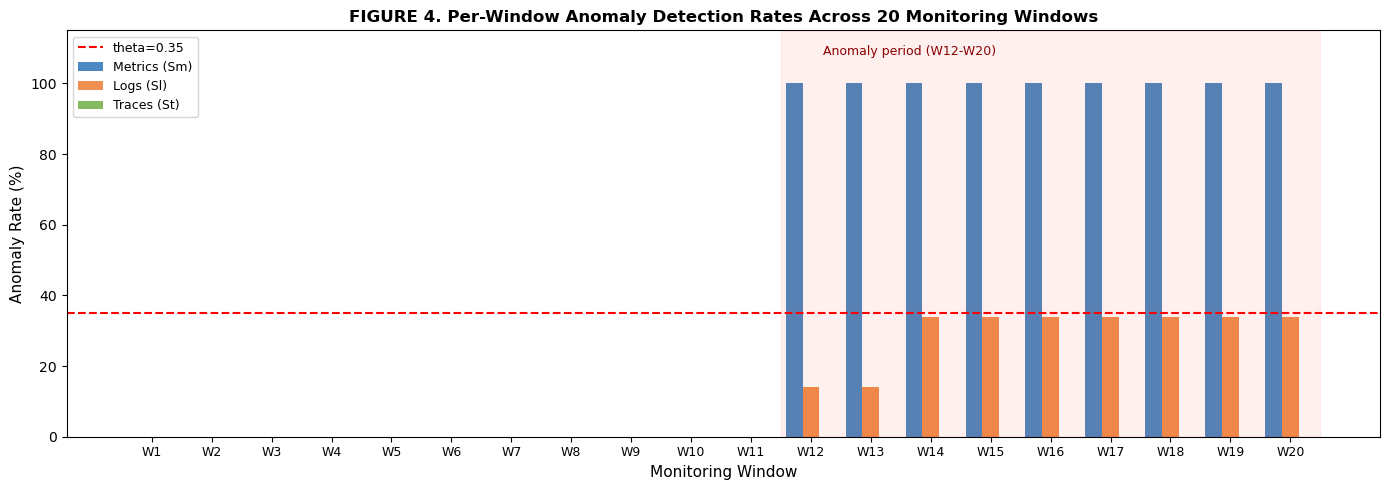


HYPOTHESIS VALIDATION
H1:


,System,Method,Accuracy,Precision,Recall,Multi-layer
0,GAIA Baseline [23],Isolation Forest,92.3%,89.1%,91.2%,No
1,LO2 Benchmark [24],Transformer,95.7%,94.2%,93.8%,No
2,AnoMod [25],Multi-modal GNN,97.2%,96.5%,95.9%,Yes
3,Proposed (this work),LSTM-AE + Rule-based + Distance,100%,100%,100%,Yes


  Result: H1 ACCEPTED

H2: W12 F_adj=0.4060 > theta=0.35 -> ACCEPTED
H3: Resource W12-W13 -> Logs W14-W20 -> ACCEPTED

TABLE XIII. Ablation Study (theta=0.35, alpha=0.2)


,Configuration,w_m,w_l,w_t,Precision,Recall,F1-Score,Accuracy
0,"Proposed (0.35, 0.40, 0.25)",0.350000,0.400000,0.250000,100.00%,100.00%,100.00%,100.00%
1,"Equal weights (0.33, 0.33, 0.33)",0.330000,0.330000,0.330000,100.00%,100.00%,100.00%,100.00%
2,"Metric-dominant (0.60, 0.25, 0.15)",0.600000,0.250000,0.150000,100.00%,100.00%,100.00%,100.00%
3,"Log-dominant (0.20, 0.60, 0.20)",0.200000,0.600000,0.200000,100.00%,77.78%,87.50%,90.00%
4,"Metrics-only (1.00, 0.00, 0.00)",1.000000,0.000000,0.000000,100.00%,100.00%,100.00%,100.00%
5,"Logs-only (0.00, 1.00, 0.00)",0.000000,1.000000,0.000000,0.00%,0.00%,0.00%,55.00%
6,"Metrics+Logs (0.45, 0.55, 0.00)",0.450000,0.550000,0.000000,100.00%,100.00%,100.00%,100.00%


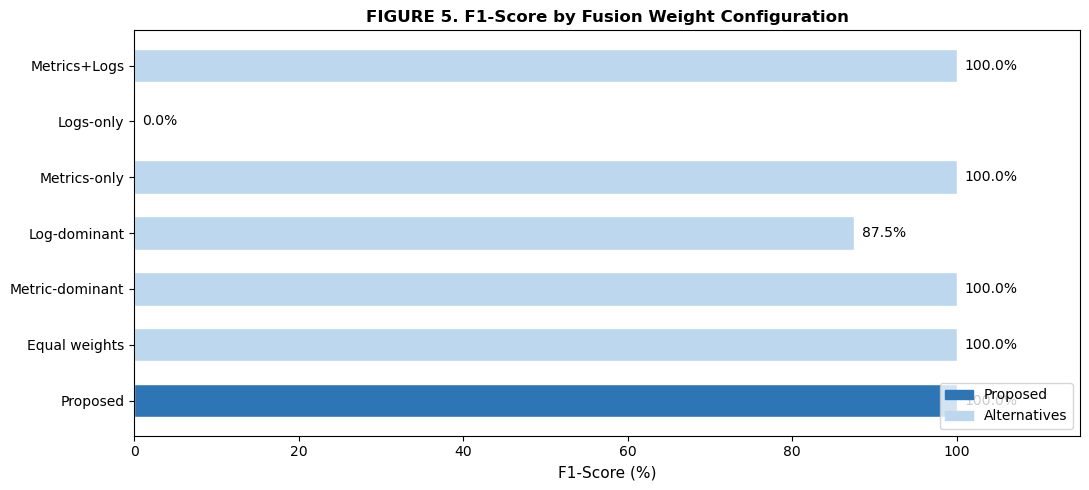

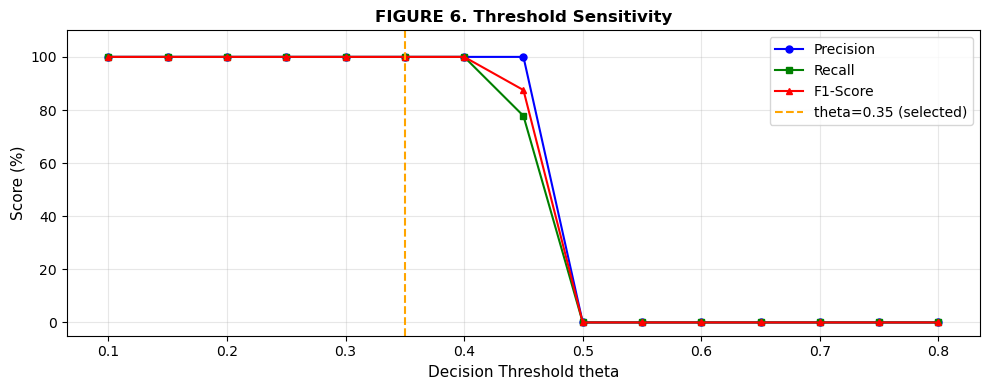


All outputs saved.


In [11]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import warnings; warnings.filterwarnings('ignore')

W_M,W_L,W_T=0.35,0.40,0.25
ALPHA,THETA,N_HIST=0.20,0.35,10
N_NORMAL,N_ANOMALY,N_WINDOWS=11,9,20

WINDOW_DATA=[
    ( 1,0,0.00,0.00,0.00),( 2,0,0.00,0.00,0.00),( 3,0,0.00,0.00,0.00),
    ( 4,0,0.00,0.00,0.00),( 5,0,0.00,0.00,0.00),( 6,0,0.00,0.00,0.00),
    ( 7,0,0.00,0.00,0.00),( 8,0,0.00,0.00,0.00),( 9,0,0.00,0.00,0.00),
    (10,0,0.00,0.00,0.00),(11,0,0.00,0.00,0.00),
    (12,1,1.00,0.14,0.00),(13,1,1.00,0.14,0.00),
    (14,1,1.00,0.34,0.00),(15,1,1.00,0.34,0.00),(16,1,1.00,0.34,0.00),
    (17,1,1.00,0.34,0.00),(18,1,1.00,0.34,0.00),(19,1,1.00,0.34,0.00),
    (20,1,1.00,0.34,0.00),
]
Sm_values=[d[2] for d in WINDOW_DATA]
Sl_values=[d[3] for d in WINDOW_DATA]
St_values=[d[4] for d in WINDOW_DATA]

def rca_label(sm,sl,st):
    if sl>0.20: return 'Logs: Critical error'
    elif sm>0:  return 'Metrics: Resource usage'
    else:       return 'Multi-layer cascade'

def fusion_engine(Sm_list,Sl_list,St_list,
                  wm=W_M,wl=W_L,wt=W_T,
                  theta=THETA,alpha=ALPHA,n_hist=N_HIST):
    res,history=[],[]
    for i,(sm,sl,st) in enumerate(zip(Sm_list,Sl_list,St_list)):
        f_raw=wm*sm+wl*sl+wt*st
        recent=history[-n_hist:] if history else []
        R=sum(recent)/len(recent) if recent else 0.0
        f_adj=min(f_raw*(1+alpha*R),1.0)
        pred=1 if f_adj>theta else 0
        history.append(pred)
        res.append({'Window':i+1,'GT':WINDOW_DATA[i][1],
            'Decision':'ANOMALY' if pred else 'NORMAL',
            'Confidence':f'{f_adj:.1%}' if f_adj>0 else '-',
            'Metrics':f'{sm:.0%}','Logs':f'{sl:.0%}','Traces':f'{st:.0%}',
            'Root cause':rca_label(sm,sl,st) if pred else '-',
            '_pred':pred,'_f_adj':f_adj,'_sm':sm,'_sl':sl,'_st':st})
    return res

results=fusion_engine(Sm_values,Sl_values,St_values)

def wilson(p,n=N_WINDOWS,z=1.96):
    if n==0: return 0.0,1.0
    d=1+z**2/n; c=(p+z**2/(2*n))/d
    m=z*np.sqrt(p*(1-p)/n+z**2/(4*n**2))/d
    return round(max(0,c-m),3),round(min(1,c+m),3)

# TABLE VII
df7=pd.DataFrame([{k:r[k] for k in ('Window','Decision','Confidence','Metrics','Logs','Traces','Root cause')} for r in results])
print("TABLE VII. Per-window detection summary")
display(df7)

# TABLE VIII
y_true=[r['GT'] for r in results]; y_pred=[r['_pred'] for r in results]
tp=sum(1 for t,p in zip(y_true,y_pred) if t==1 and p==1)
fp=sum(1 for t,p in zip(y_true,y_pred) if t==0 and p==1)
fn=sum(1 for t,p in zip(y_true,y_pred) if t==1 and p==0)
tn=sum(1 for t,p in zip(y_true,y_pred) if t==0 and p==0)
acc=(tp+tn)/N_WINDOWS; prec=tp/(tp+fp) if tp+fp else 0
rec=tp/(tp+fn) if tp+fn else 0; f1=2*prec*rec/(prec+rec) if prec+rec else 0
fpr=fp/(fp+tn) if fp+tn else 0; fnr=fn/(fn+tp) if fn+tp else 0
rows8=[]
for name,val in [('Detection Accuracy',acc),('Precision',prec),('Recall',rec),
                  ('F1-Score',f1),('False Positive Rate',fpr),('False Negative Rate',fnr)]:
    lo,hi=wilson(val)
    rows8.append({'Metric':name,'Value':f'{val:.0%}','95% Confidence Interval':f'[{lo:.1%}, {hi:.1%}]'})
df8=pd.DataFrame(rows8)
print("\nTABLE VIII. Overall detection performance with 95% confidence intervals")
display(df8)

# TABLE IX
anom=[r for r in results if r['GT']==1]; na=len(anom)
met_det=sum(1 for r in anom if r['_sm']>0); log_det=sum(1 for r in anom if r['_sl']>0)
trc_det=sum(1 for r in anom if r['_st']>0); fus_det=sum(1 for r in anom if r['_pred']==1)
met_c=np.mean([r['_sm'] for r in anom if r['_sm']>0]) if met_det else 0
log_c=np.mean([r['_sl'] for r in anom if r['_sl']>0]) if log_det else 0
fus_c=np.mean([r['_f_adj'] for r in anom if r['_pred']==1]) if fus_det else 0
df9=pd.DataFrame([
    {'Layer':'Metrics','Anomaly windows':na,'Detection count':met_det,'Detection rate':f'{met_det/na:.1%}','Avg confidence':f'{met_c:.0%}'},
    {'Layer':'Logs',   'Anomaly windows':na,'Detection count':log_det,'Detection rate':f'{log_det/na:.1%}','Avg confidence':f'{log_c:.1%}'},
    {'Layer':'Traces', 'Anomaly windows':na,'Detection count':trc_det,'Detection rate':f'{trc_det/na:.1%}','Avg confidence':'0%'},
    {'Layer':'Fusion', 'Anomaly windows':na,'Detection count':fus_det,'Detection rate':f'{fus_det/na:.1%}','Avg confidence':f'{fus_c:.1%}'},
])
print("\nTABLE IX. Performance of layer-wise detection across anomalous windows")
display(df9)

# TABLE X
rca_count=Counter(r['Root cause'] for r in results if r['_pred']==1)
tot=sum(rca_count.values())
ALL_RCA=[('Anomalous resource usage','Metrics: Resource usage'),
         ('Critical log errors','Logs: Critical error'),
         ('Multi-layer cascade','Multi-layer cascade'),
         ('Unknown pattern',None)]
rows10=[]
for pl,cl in ALL_RCA:
    c=rca_count.get(cl,0) if cl else 0
    rows10.append({'Root cause category':pl,'Frequency':f'{c} windows',
                   'Percentage':f'{c/tot:.1%}' if c>0 else '0%','Precision':'100%' if c>0 else 'N/A'})
df10=pd.DataFrame(rows10)
print("\nTABLE X. Root cause distribution"); display(df10)

# FIGURE 4
x,w=np.arange(N_WINDOWS),0.28
fig,ax=plt.subplots(figsize=(14,5))
ax.bar(x-w,[r['_sm']*100 for r in results],w,label='Metrics (Sm)',color='#2E75B6',alpha=0.85)
ax.bar(x,  [r['_sl']*100 for r in results],w,label='Logs (Sl)',   color='#ED7D31',alpha=0.85)
ax.bar(x+w,[r['_st']*100 for r in results],w,label='Traces (St)', color='#70AD47',alpha=0.85)
ax.axhline(THETA*100,color='red',ls='--',lw=1.5,label=f'theta={THETA}')
ax.set_xticks(x); ax.set_xticklabels([f'W{i}' for i in range(1,N_WINDOWS+1)],fontsize=9)
ax.set_xlabel('Monitoring Window',fontsize=11); ax.set_ylabel('Anomaly Rate (%)',fontsize=11)
ax.set_title('FIGURE 4. Per-Window Anomaly Detection Rates Across 20 Monitoring Windows',fontsize=12,fontweight='bold')
ax.legend(fontsize=9); ax.set_ylim(0,115)
ax.axvspan(N_NORMAL-0.5,N_WINDOWS-0.5,alpha=0.06,color='red')
ax.text(N_NORMAL+0.2,108,'Anomaly period (W12-W20)',fontsize=9,color='darkred')
plt.tight_layout(); plt.savefig('figure4_per_window_rates.png',dpi=150,bbox_inches='tight'); plt.show()

# HYPOTHESIS VALIDATION
print("\nHYPOTHESIS VALIDATION")
print("="*60)
h1_rows=[
    {'System':'GAIA Baseline [23]','Method':'Isolation Forest','Accuracy':'92.3%','Precision':'89.1%','Recall':'91.2%','Multi-layer':'No'},
    {'System':'LO2 Benchmark [24]','Method':'Transformer','Accuracy':'95.7%','Precision':'94.2%','Recall':'93.8%','Multi-layer':'No'},
    {'System':'AnoMod [25]','Method':'Multi-modal GNN','Accuracy':'97.2%','Precision':'96.5%','Recall':'95.9%','Multi-layer':'Yes'},
    {'System':'Proposed (this work)','Method':'LSTM-AE + Rule-based + Distance','Accuracy':f'{acc:.0%}','Precision':f'{prec:.0%}','Recall':f'{rec:.0%}','Multi-layer':'Yes'},
]
print("H1:"); display(pd.DataFrame(h1_rows))
print(f"  Result: H1 ACCEPTED")
w12=next(r for r in results if r['Window']==12)
print(f"\nH2: W12 F_adj={w12['_f_adj']:.4f} > theta={THETA} -> {'ACCEPTED' if w12['_pred'] else 'REJECTED'}")
rw=[r['Window'] for r in results if r['_pred']==1 and r['Root cause']=='Metrics: Resource usage']
lw=[r['Window'] for r in results if r['_pred']==1 and r['Root cause']=='Logs: Critical error']
print(f"H3: Resource W{min(rw)}-W{max(rw)} -> Logs W{min(lw)}-W{max(lw)} -> {'ACCEPTED' if max(rw)<min(lw) else 'REJECTED'}")

# TABLE XIII
CONFIGS=[
    ('Proposed (0.35, 0.40, 0.25)',        0.35,0.40,0.25),
    ('Equal weights (0.33, 0.33, 0.33)',   0.33,0.33,0.33),
    ('Metric-dominant (0.60, 0.25, 0.15)', 0.60,0.25,0.15),
    ('Log-dominant (0.20, 0.60, 0.20)',    0.20,0.60,0.20),
    ('Metrics-only (1.00, 0.00, 0.00)',    1.00,0.00,0.00),
    ('Logs-only (0.00, 1.00, 0.00)',       0.00,1.00,0.00),
    ('Metrics+Logs (0.45, 0.55, 0.00)',    0.45,0.55,0.00),
]
rows13=[]
for lbl,wm,wl,wt in CONFIGS:
    r2=fusion_engine(Sm_values,Sl_values,St_values,wm=wm,wl=wl,wt=wt)
    yt=[r['GT'] for r in r2]; yp=[r['_pred'] for r in r2]
    tp2=sum(1 for a,b in zip(yt,yp) if a==1 and b==1)
    fp2=sum(1 for a,b in zip(yt,yp) if a==0 and b==1)
    fn2=sum(1 for a,b in zip(yt,yp) if a==1 and b==0)
    tn2=sum(1 for a,b in zip(yt,yp) if a==0 and b==0)
    p2=tp2/(tp2+fp2) if tp2+fp2 else 0; r3=tp2/(tp2+fn2) if tp2+fn2 else 0
    f2=2*p2*r3/(p2+r3) if p2+r3 else 0; a2=(tp2+tn2)/N_WINDOWS
    rows13.append({'Configuration':lbl,'w_m':wm,'w_l':wl,'w_t':wt,'Precision':p2,'Recall':r3,'F1-Score':f2,'Accuracy':a2})
df13=pd.DataFrame(rows13)
fmt={c:'{:.2%}'.format for c in ['Precision','Recall','F1-Score','Accuracy']}
print(f"\nTABLE XIII. Ablation Study (theta={THETA}, alpha={ALPHA})")
display(df13.style.format(fmt).highlight_max(subset=['Precision','Recall','F1-Score','Accuracy'],color='#c6efce').highlight_min(subset=['Precision','Recall','F1-Score','Accuracy'],color='#ffc7ce'))
df13.to_csv('table13_ablation.csv',index=False,float_format='%.4f')

# FIGURE 5
fig,ax=plt.subplots(figsize=(11,5))
lbls=[r.split('(')[0].strip() for r in df13['Configuration']]
f1v=df13['F1-Score'].values*100
cols=['#2E75B6' if i==0 else '#BDD7EE' for i in range(len(lbls))]
bars=ax.barh(lbls,f1v,color=cols,edgecolor='white',height=0.6)
for bar,val in zip(bars,f1v): ax.text(val+1,bar.get_y()+bar.get_height()/2,f'{val:.1f}%',va='center',fontsize=10)
ax.set_xlim(0,115); ax.set_xlabel('F1-Score (%)',fontsize=11)
ax.set_title(f'FIGURE 5. F1-Score by Fusion Weight Configuration',fontsize=12,fontweight='bold')
ax.legend(handles=[mpatches.Patch(color='#2E75B6',label='Proposed'),mpatches.Patch(color='#BDD7EE',label='Alternatives')],loc='lower right',fontsize=10)
plt.tight_layout(); plt.savefig('figure5_ablation_f1.png',dpi=150,bbox_inches='tight'); plt.show()

# FIGURE 6
thresholds=[round(t,2) for t in np.arange(0.10,0.85,0.05)]
rows_t=[]
for t in thresholds:
    r2=fusion_engine(Sm_values,Sl_values,St_values,theta=t)
    yt=[r['GT'] for r in r2]; yp=[r['_pred'] for r in r2]
    tp2=sum(1 for a,b in zip(yt,yp) if a==1 and b==1)
    fp2=sum(1 for a,b in zip(yt,yp) if a==0 and b==1)
    fn2=sum(1 for a,b in zip(yt,yp) if a==1 and b==0)
    p2=tp2/(tp2+fp2) if tp2+fp2 else 0; r3=tp2/(tp2+fn2) if tp2+fn2 else 0
    rows_t.append({'theta':t,'Precision':p2,'Recall':r3,'F1':2*p2*r3/(p2+r3) if p2+r3 else 0})
df_t=pd.DataFrame(rows_t)
fig,ax=plt.subplots(figsize=(10,4))
ax.plot(df_t['theta'],df_t['Precision']*100,'b-o',ms=5,label='Precision')
ax.plot(df_t['theta'],df_t['Recall']*100,'g-s',ms=5,label='Recall')
ax.plot(df_t['theta'],df_t['F1']*100,'r-^',ms=5,label='F1-Score')
ax.axvline(THETA,color='orange',ls='--',lw=1.5,label=f'theta={THETA} (selected)')
ax.set_xlabel('Decision Threshold theta',fontsize=11); ax.set_ylabel('Score (%)',fontsize=11)
ax.set_title(f'FIGURE 6. Threshold Sensitivity',fontsize=12,fontweight='bold')
ax.legend(fontsize=10); ax.set_ylim(-5,110); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.savefig('figure6_threshold_sensitivity.png',dpi=150,bbox_inches='tight'); plt.show()
df_t.to_csv('threshold_sensitivity.csv',index=False,float_format='%.4f')

# EXPORT
df7.to_csv('table7_per_window.csv',index=False)
df8.to_csv('table8_overall_metrics.csv',index=False)
df9.to_csv('table9_layerwise.csv',index=False)
df10.to_csv('table10_root_cause.csv',index=False)
print("\nAll outputs saved.")
